# **NCCU Deep Learning**
## *Programming Assignment #2*

### Convolutional Neural Networks
In this programming assignment, we will learn to train a convolutional neural networks (CNN) and how to use them to make predictions.  We will be using CIFAR-100 dataset for this example notebook.

In Program Assignment #1, you used MLP to train CIFAR-100 dataset.
In this assignment, try to train the dataset using a simple CNN network, look for the best setting, and try to do transfer learning, and explore for different classic modules.


**Your assignment:**

*   Clone the notebook
*   Follow the example below, start with the provided baseline CNN and train it on CIFAR-100.
*   Modify the depth or width of the baseline CNN
*   Add residual blocks to your baseline CNN.
*   Use a standard ResNet-18 architecture without pretrained weights.
*   Use a pretrained ResNet-18 model (trained on ImageNet) and fine-tune it on CIFAR-100.

Don't worry, all the details are below!


**Before we dive into the model part, everything up to this point is exactly the same as the previous assignment — so you can focus entirely on the model this time!**


In [12]:
import random
import numpy as np
import torch

SEED = 9999
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

print("Random sample (Python):", random.random())
print("Random sample (NumPy):", np.random.rand())
print("Random sample (PyTorch):", torch.rand(1).item())

Random sample (Python): 0.8347577610922152
Random sample (NumPy): 0.8233890742543671
Random sample (PyTorch): 0.7876027822494507


In [13]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load the full CIFAR-100 training dataset (all 100 classes)
trainset = datasets.CIFAR100(
    root='../data', train=True, download=True, transform=transform)

# Load the full CIFAR-100 test dataset (all 100 classes)
testset = datasets.CIFAR100(
    root='../data', train=False, download=True, transform=transform)
print(f'Number of training images (100 classes): {len(trainset)}')
print(f'Number of testing images (100 classes): {len(testset)}')

Number of training images (100 classes): 50000
Number of testing images (100 classes): 10000


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_images(images, labels=None, classes=None):
    n_images = len(images)
    rows = int(np.sqrt(n_images))
    cols = int(np.ceil(n_images / rows))

    fig = plt.figure(figsize=(cols , rows))
    for i in range(n_images):
        ax = fig.add_subplot(rows, cols, i + 1)

        # tensor shape: (C, H, W) → (H, W, C)
        img = images[i].permute(1, 2, 0).cpu().numpy()

        # unnormalize if needed
        img = np.clip(img, 0, 1)

        ax.imshow(img)
        ax.axis('off')

        if labels is not None and classes is not None:
            ax.set_title(classes[labels[i]])

    plt.tight_layout()
    plt.show()

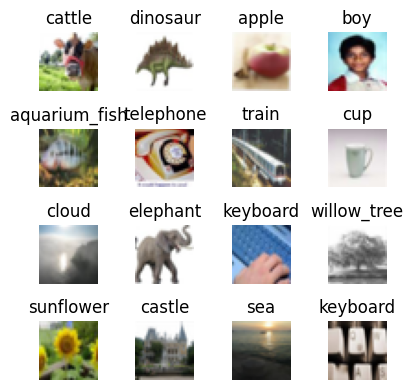

In [15]:
images = [trainset[i][0] for i in range(16)]
labels = [trainset[i][1] for i in range(16)]
classes = trainset.classes

plot_images(images, labels, classes)

In [16]:
import torch.utils.data as data

BATCH_SIZE = 8

train_iterator = data.DataLoader(trainset, shuffle=True, batch_size=BATCH_SIZE)
test_iterator = data.DataLoader(testset, batch_size=BATCH_SIZE)

images, labels = next(iter(train_iterator))

print(f"[INFO] Shape of one batch of images: {images.shape}")
print(f"[INFO] Shape of one batch of labels: {labels.shape}")

[INFO] Shape of one batch of images: torch.Size([8, 3, 32, 32])
[INFO] Shape of one batch of labels: torch.Size([8])


# Convolutional Neural Network (CNN)

---

**🧱 Baseline CNN: Simple Convolutional Neural Network**

We begin by defining a simple CNN model as our baseline.  
This model consists of three convolutional layers, each followed by ReLU activation and max pooling, which progressively reduce the spatial dimensions while increasing the number of channels.

After the convolutional feature extraction, the output is flattened and passed through two fully connected layers with dropout in between to reduce overfitting.

This network is relatively shallow, making it a good starting point for experiments.


---
## Define the Network [Architecture](http://pytorch.org/docs/stable/nn.html)

This time, you'll define a CNN architecture. Instead of an MLP, which used linear, fully-connected layers, you'll use the following:
* [Convolutional layers](https://pytorch.org/docs/stable/nn.html#conv2d), which can be thought of as stack of filtered images.
* [Maxpooling layers](https://pytorch.org/docs/stable/nn.html#maxpool2d), which reduce the x-y size of an input, keeping only the most _active_ pixels from the previous layer.
* The usual Linear + Dropout layers to avoid overfitting and produce a 100-dim output.

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F

#############################################################
# Task 4.2: Load pretrained ResNet-18 and adapt for CIFAR-100

# Load ResNet-18 (with pretrained weights!)
model = models.resnet18(pretrained = True)

# Replace final fully connected layer to match 100 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 100)
# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model = model.to(device)
print("ResNet-18 model loaded and adapted for CIFAR-100.")

#############################################################


Using device: cpu
ResNet-18 model loaded and adapted for CIFAR-100.


In [18]:

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [19]:
from torchsummary import summary
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
summary(model,(3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 16, 16]           9,408
       BatchNorm2d-2           [-1, 64, 16, 16]             128
              ReLU-3           [-1, 64, 16, 16]               0
         MaxPool2d-4             [-1, 64, 8, 8]               0
            Conv2d-5             [-1, 64, 8, 8]          36,864
       BatchNorm2d-6             [-1, 64, 8, 8]             128
              ReLU-7             [-1, 64, 8, 8]               0
            Conv2d-8             [-1, 64, 8, 8]          36,864
       BatchNorm2d-9             [-1, 64, 8, 8]             128
             ReLU-10             [-1, 64, 8, 8]               0
       BasicBlock-11             [-1, 64, 8, 8]               0
           Conv2d-12             [-1, 64, 8, 8]          36,864
      BatchNorm2d-13             [-1, 64, 8, 8]             128
             ReLU-14             [-1, 6

In [20]:
from tqdm.notebook import tqdm

def calculate_accuracy(y_pred, y):
    top_pred = y_pred.argmax(1, keepdim=True)
    correct = top_pred.eq(y.view_as(top_pred)).sum()
    acc = correct.float() / y.shape[0]
    return acc

def train(model, iterator, optimizer, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for (x, y) in tqdm(iterator, desc="Training", leave=False):

        x = x.to(device)
        y = y.to(device)

        #add code below
        # Reset gradients from the previous iteration (avoid accumulation)
        # Forward pass: compute logits/predictions for this batch
        # Compute scalar loss for this batch (e.g., CrossEntropy)
        # Compute a metric for monitoring (e.g., top-1 accuracy)
        # Backward pass: compute gradients w.r.t. all learnable parameters
        # Optimizer step: update parameters using computed gradients
        #add code above

        #############################################################
        # Exercise 1.2: Complete baseline training code and train the original CNN model until convergence

        # Reset gradients from the previous iteration (avoid accumulation)
        optimizer.zero_grad()

        # Forward pass: compute logits/predictions for this batch
        y_pred = model(x)

        # Compute scalar loss for this batch (e.g., CrossEntropy)
        loss = criterion(y_pred, y)

        # Compute a metric for monitoring (e.g., top-1 accuracy)
        acc = calculate_accuracy(y_pred, y)

        # Backward pass: compute gradients w.r.t. all learnable parameters
        loss.backward()

        # Optimizer step: update parameters using computed gradients
        optimizer.step()
        
        #############################################################

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

def evaluate(model, iterator, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.eval()

    with torch.no_grad():

        for (x, y) in tqdm(iterator, desc="Evaluating", leave=False):

            x = x.to(device)
            y = y.to(device)

            y_pred = model(x)

            loss = criterion(y_pred, y)

            acc = calculate_accuracy(y_pred, y)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

---

**⚙️ Training Function: `train_model()`**

In this step, we've wrapped the training process into a reusable function called `train_model()`.

This means you no longer need to repeat the training loop every time — just modify your model structure, call `train_model()`, and you're ready to train!

The function handles training, validation, loss tracking, and automatic saving of the best model.


In [21]:
import time
import torch.optim as optim

def train_model(model, train_iterator, test_iterator, device,
                epochs=5, lr=0.01, model_path='best-model.pt'):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss().to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)

    best_valid_loss = float('inf')

    train_losses = []
    train_accuracies = []
    valid_losses = []
    valid_accuracies = []

    for epoch in tqdm(range(epochs)):

        start_time = time.monotonic()

        train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
        valid_loss, valid_acc = evaluate(model, test_iterator, criterion, device)

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), model_path)

        end_time = time.monotonic()
        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
        print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
        print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        valid_losses.append(valid_loss)
        valid_accuracies.append(valid_acc)

    return {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'valid_losses': valid_losses,
        'valid_accuracies': valid_accuracies,
        'best_model_path': model_path
    }

In [22]:
stats = train_model(
    model=model,
    train_iterator=train_iterator,
    test_iterator=test_iterator,
    device=device,
    epochs=80
)

  0%|          | 0/80 [00:00<?, ?it/s]

Training:   0%|          | 0/6250 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch: 01 | Epoch Time: 3m 33s
	Train Loss: 3.489 | Train Acc: 17.83%
	 Val. Loss: 2.792 |  Val. Acc: 31.57%


Training:   0%|          | 0/6250 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch: 79 | Epoch Time: 3m 55s
	Train Loss: 0.092 | Train Acc: 97.12%
	 Val. Loss: 3.316 |  Val. Acc: 50.73%


Training:   0%|          | 0/6250 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch: 80 | Epoch Time: 3m 52s
	Train Loss: 0.093 | Train Acc: 97.03%
	 Val. Loss: 3.398 |  Val. Acc: 50.33%


**🧪 Final Evaluation**

Just like in the previous assignment, we evaluate our trained model on the test set to see how well it performs after training.  
This gives us an objective measure of how well our model generalizes to unseen data.

In [23]:
model.load_state_dict(torch.load('best-model.pt'))
criterion = nn.CrossEntropyLoss().to(device)
test_loss, test_acc = evaluate(model, test_iterator, criterion, device)

print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Evaluating:   0%|          | 0/1250 [00:00<?, ?it/s]

Test Loss: 1.917 | Test Acc: 51.52%


In [24]:
def get_predictions(model, iterator, device):

    model.eval()

    images = []
    labels = []
    probs = []

    with torch.no_grad():

        for (x, y) in iterator:

            x = x.to(device)

            y_pred = model(x)

            y_prob = F.softmax(y_pred, dim=-1)

            images.append(x.cpu())
            labels.append(y.cpu())
            probs.append(y_prob.cpu())

    images = torch.cat(images, dim=0)
    labels = torch.cat(labels, dim=0)
    probs = torch.cat(probs, dim=0)

    return images, labels, probs

In [ ]:
images, labels, probs = get_predictions(model, test_iterator, device)

pred_labels = torch.argmax(probs, 1)
corrects = torch.eq(labels, pred_labels)

incorrect_examples = []

for image, label, prob, correct in zip(images, labels, probs, corrects):
    if not correct:
        incorrect_examples.append((image, label, prob))

incorrect_examples.sort(reverse=True,
                        key=lambda x: torch.max(x[2], dim=0).values)

In [27]:
def plot_most_incorrect(incorrect, n_images, class_names=None):
    rows = int(np.sqrt(n_images))
    cols = int(np.ceil(n_images / rows))

    fig = plt.figure(figsize=(cols * 1.5, rows * 1.5))
    for i in range(rows * cols):
        ax = fig.add_subplot(rows, cols, i + 1)

        image, true_label, probs = incorrect[i]
        true_prob = probs[true_label].item()
        incorrect_prob, incorrect_label = torch.max(probs, dim=0)
        incorrect_prob = incorrect_prob.item()
        incorrect_label = incorrect_label.item()

        # Prepare image for display
        img = image.permute(1, 2, 0).cpu().numpy()  # (C, H, W) → (H, W, C)
        img = np.clip(img, 0, 1)
        ax.imshow(img)

        # Set title for each subplot
        if class_names:
            title = f'True: {class_names[true_label]} ({true_prob:.2f})\nPred: {class_names[incorrect_label]} ({incorrect_prob:.2f})'
        else:
            title = f'True: {true_label} ({true_prob:.2f})\nPred: {incorrect_label} ({incorrect_prob:.2f})'

        ax.set_title(title, fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

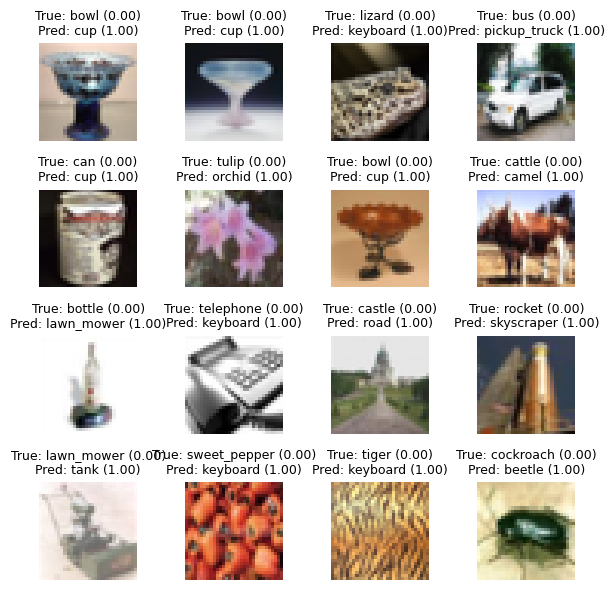

In [28]:
plot_most_incorrect(incorrect_examples, 16, class_names=trainset.classes)

# 🛠️ TO DO

## 📌 Submission Guidelines

Please submit **both** of the following files:

---

### 📄 Report (PDF)

Your PDF should include:
- Answers to all conceptual questions
- Training and validation metrics (loss/accuracy) for each setting
- If you made **any code modifications** during experiments (e.g., changing dropout rate, adding regularization, etc.), please **include screenshots** of the modified code in the PDF

---

### 🧑‍💻 Code File (`.ipynb`)

Submit only your **final version** of the notebook:
- Ensure the notebook runs without error
- Include necessary comments
- Make sure all relevant outputs are shown

⚠️ If intermediate changes are not documented in your PDF, **full credit may not be given**!

---

### 🗂 File Naming Convention

To help us clearly identify the owner of each submission, please **follow this naming format**:

- Notebook file: `your_name_DL_Assignment_#.ipynb`  
- Report file: `your_name_DL_Assignment_#.pdf`

> Replace `your_name` with your full name and `#` with the assignment number.

✅ **Example**:  
- `Sheng-An_Wang_DL_Assignment_2.ipynb`  
- `Sheng-An Wang_DL_Assignment_2.pdf`

---
Convolutional Neural Networks (CNNs) are the backbone of modern computer vision.  
This assignment aims to help you understand how model structure affects performance.  
By starting with a simple CNN and gradually exploring deeper architectures, residual connections, and pretrained models, you'll gain practical insights into how CNNs learn to recognize visual patterns—and how thoughtful design choices can make a big difference.


---

## 📝 What You Must Do

### 1. Baseline CNN: Make It Deeper (30%)

The CNN provided in the example code is intentionally incomplete.  
Your task is to modify and experiment with it:

- 📐 Complete the baseline CNN model code to have **3 convolutional layers**
   based on the comments in the provided code block, we have already defined the structure of each block.
   *(⚠️ Hint: Each max pooling reduces the spatial size by half — make sure your tensor shapes still match in the `forward()` function!)* (10%)

- 🧪 Complete baseline training code and Train the original CNN until convergence (5%)

- 📐 Extend the baseline CNN from **3 convolutional layers to 5 layers**.  
   You can decide the number of channels for each layer. (5%)

- 🧪 Train the modified CNN until convergence and compare it with the original simple CNN, adjust the number of epochs if needed. (5%)

- Which one is better, and why? (5%)


💡 **Hint:**  
Once you've defined your model, you can train and evaluate it using the `train_model()` function:

```python
stats = train_model(
    model=your_model,
    train_iterator=train_iterator,
    test_iterator=test_iterator,
    device=device
)
```
and use the function 'evaluate' to see the loss and accuracy.


---
### 2. Residual Block: To Be Even Deeper (15%)

Residual connections were introduced in ResNet to solve the **degradation problem** — where deeper networks sometimes perform worse than shallower ones due to optimization difficulties.  
A **residual block** allows the network to learn identity mappings more easily, making it easier to train deeper architectures.

- 📖 **What is a residual block?**  
  In your own words, briefly explain what it is and why it was introduced.  
  *(Hint: Think about vanishing gradients and training stability.)* (5%)

- 🔧 **Modify your improved CNN from Step 1**  
  Replace **two of your convolutional layers** with **residual modules**.  
  (You can either define a custom `ResidualBlock` class or directly implement the skip connections inside your `forward()` function.) (5%)


- 🧪 **Train your new residual CNN and compare**  
  Evaluate the model and compare the results with previous models, and answer: Which one performs better, and why do you think that is? (5%)
---
### 3. Classic Architecture: ResNet-18 from Scratch (15%)

Now that you've tried building residual blocks on your own, it's time to explore a classic deep architecture: **ResNet-18**.

- 📖 **What is ResNet-18?**  
  In your own words, explain what ResNet-18 is and why it's a well-known architecture. (5%)

- 🔍 **Compare ResNet-18, 34, and 50**  
  What's the difference between these versions in terms of architecture, depth, and use cases? (5%)

- 🧪 **Train ResNet-18 from scratch (no pretrained weights)**  
  Use `torchvision.models.resnet18(pretrained=False)` to load the model, modify the final layer to fit 100 classes, and train it on CIFAR-100.  
  Compare the result with your previous CNNs — how does it perform? (5%)

💡 You can load the model using:

`models.resnet18(pretrained=False)` loads an untrained ResNet-18 model.  
To use it for CIFAR-100, remember to replace the final fully connected layer like this:

```python
import torchvision.models as models

resnet18 = models.resnet18(pretrained=False)  # 👈 load from scratch
resnet18.fc = nn.Linear(resnet18.fc.in_features, 100)  # for CIFAR-100
resnet18 = resnet18.to(device)
```
---
### 4. Transfer Learning: Using Pretrained ResNet-18 (20%)

Transfer learning allows us to reuse the knowledge learned from one task (like ImageNet classification) and apply it to another (like CIFAR-100).  This is especially useful when the target dataset is small or when we want to speed up training.

- 📖 **What is transfer learning, and what problem is it trying to solve?**  
  Briefly explain the core idea behind transfer learning and why it is useful in deep learning.(5%)

- 🧪 **Load and fine-tune a pretrained ResNet-18**  
  Use `models.resnet18(pretrained=True)` and replace the final layer to match 100 classes, to train the model on CIFAR-100 and record the results.(5%)

- 🔍 **Compare the performance**  
  How does the pretrained ResNet-18 compare to all models in the previous steps. (5%)

- ❓ **Is transfer learning always better?**  
  Share your thoughts: What are the potential risks or limitations of transfer learning?  
  (e.g., domain mismatch, overfitting to small data, feature mismatch, etc.) (5%)

---

## 🌟 More Ways of Classic Deep Learning Modules (20%)

- 🛠️ **Inception Module**  
  Replace the residual blocks from Step 2 with an Inception-style design.  
  For example, you might apply `1x1`, `3x3`, and `5x5` convolutions in parallel and concatenate their outputs. (10%)

- 🧩 **DenseNet-style Module**  
  Try implementing a DenseNet-style block, where each layer receives the concatenated outputs from all previous layers in the block.  
  This encourages feature reuse and improves gradient flow. You can use `torch.cat()` to concatenate feature maps inside the block. (10%)

---

## 🙌 Credits
Assignment designed by TAs: Sheng-An Wang and Zi-Hao Chen.  
